# Student Risk Prediction System

This project predicts students who are at risk of academic failure using XGBoost and provides personalized intervention recommendations. SHAP is used to explain model predictions.

In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("student-mat.csv", sep=";")

In [4]:
df.sample(5)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
340,GP,F,19,U,GT3,T,2,1,services,services,...,4,3,4,1,3,3,4,11,12,11
111,GP,F,16,R,GT3,T,3,3,services,other,...,4,1,2,1,1,2,0,7,10,10
127,GP,F,19,U,GT3,T,0,1,at_home,other,...,3,4,2,1,1,5,2,7,8,9
352,MS,M,18,U,LE3,T,1,3,at_home,services,...,4,3,3,2,3,3,7,8,7,8
166,GP,M,16,U,GT3,T,2,2,other,other,...,4,3,5,2,4,4,4,10,10,10


# EDA

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher      395 non-null    str  
 21  inte

In [6]:
df.shape

(395, 33)

In [7]:
df.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

In [8]:
df.iloc[2]

school             GP
sex                 F
age                15
address             U
famsize           LE3
Pstatus             T
Medu                1
Fedu                1
Mjob          at_home
Fjob            other
reason          other
guardian       mother
traveltime          1
studytime           2
failures            3
schoolsup         yes
famsup             no
paid              yes
activities         no
nursery           yes
higher            yes
internet          yes
romantic           no
famrel              4
freetime            3
goout               2
Dalc                2
Walc                3
health              3
absences           10
G1                  7
G2                  8
G3                 10
Name: 2, dtype: object

In [9]:
df['famsize'].value_counts()

famsize
GT3    281
LE3    114
Name: count, dtype: int64

In [10]:
df['Fjob'].value_counts()

Fjob
other       217
services    111
teacher      29
at_home      20
health       18
Name: count, dtype: int64

In [11]:
df['Mjob'].value_counts()

Mjob
other       141
services    103
at_home      59
teacher      58
health       34
Name: count, dtype: int64

In [12]:
df['risk'] = (df['G3'] < 10).astype(int)

In [13]:
df['G3'].value_counts()

G3
10    56
11    47
0     38
15    33
8     32
12    31
13    31
9     28
14    27
16    16
6     15
18    12
7      9
5      7
17     6
19     5
20     1
4      1
Name: count, dtype: int64

In [14]:
df['risk'].value_counts()

risk
0    265
1    130
Name: count, dtype: int64

<Axes: xlabel='risk', ylabel='count'>

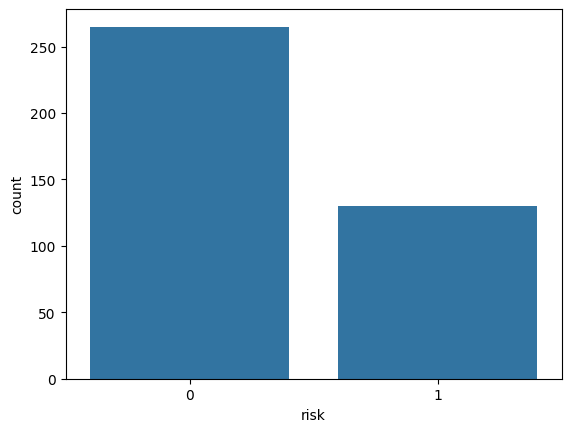

In [15]:
sns.countplot(data=df,x='risk')

In [16]:
df[["studytime","failures","absences","G1","G2","G3"]].corr()

,studytime,failures,absences,G1,G2,G3
studytime,1.000000,-0.173563,-0.062700,0.160612,0.135880,0.097820
failures,-0.173563,1.000000,0.063726,-0.354718,-0.355896,-0.360415
absences,-0.062700,0.063726,1.000000,-0.031003,-0.031777,0.034247
G1,0.160612,-0.354718,-0.031003,1.000000,0.852118,0.801468
G2,0.135880,-0.355896,-0.031777,0.852118,1.000000,0.904868
G3,0.097820,-0.360415,0.034247,0.801468,0.904868,1.000000


# Preprocessing & Training

In [17]:
X = df.drop(
    columns=["risk", "G3"]
).copy()

y = df["risk"]

In [18]:
# convert all string columns to normal object columns
for col in X.select_dtypes(include=["string"]).columns:
    X[col] = X[col].astype("object")

In [19]:
cat_cols = X.select_dtypes(
    include=["object", "string"]
).columns

num_cols = X.select_dtypes(
    exclude=["object", "string"]
).columns

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            cat_cols
        )
    ],
    remainder="passthrough"
)

In [22]:
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

xgb_model_B = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            XGBClassifier(
                n_estimators=200,
                max_depth=4,
                learning_rate=0.05,
                random_state=42,
                eval_metric="logloss"
            )
        )
    ]
)

In [23]:
xgb_model_B.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [24]:
y_pred_B = xgb_model_B.predict(
    X_test
)

# Metrics

In [25]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_B
    )
)

              precision    recall  f1-score   support

           0       0.93      0.94      0.93        53
           1       0.88      0.85      0.86        26

    accuracy                           0.91        79
   macro avg       0.90      0.89      0.90        79
weighted avg       0.91      0.91      0.91        79



In [26]:
from sklearn.metrics import accuracy_score

accuracy_score(
    y_test,
    y_pred_B
)

0.9113924050632911

# Shap

In [27]:
import shap

In [28]:
X_test_transformed = xgb_model_B.named_steps[
    "preprocessor"
].transform(X_test)

feature_names = xgb_model_B.named_steps[
    "preprocessor"
].get_feature_names_out()

xgb = xgb_model_B.named_steps[
    "classifier"
]

In [29]:
explainer = shap.TreeExplainer(xgb)

In [30]:
shap_values = explainer.shap_values(
    X_test_transformed
)

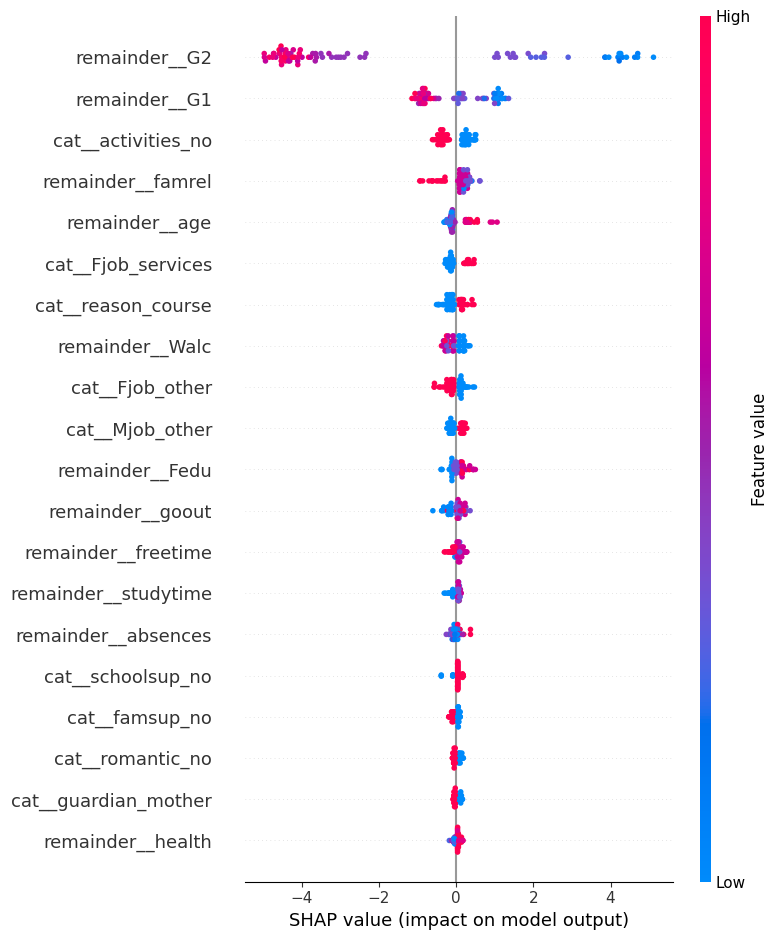

In [50]:
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    show=False
)

plt.tight_layout()
plt.savefig(
    "shap_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

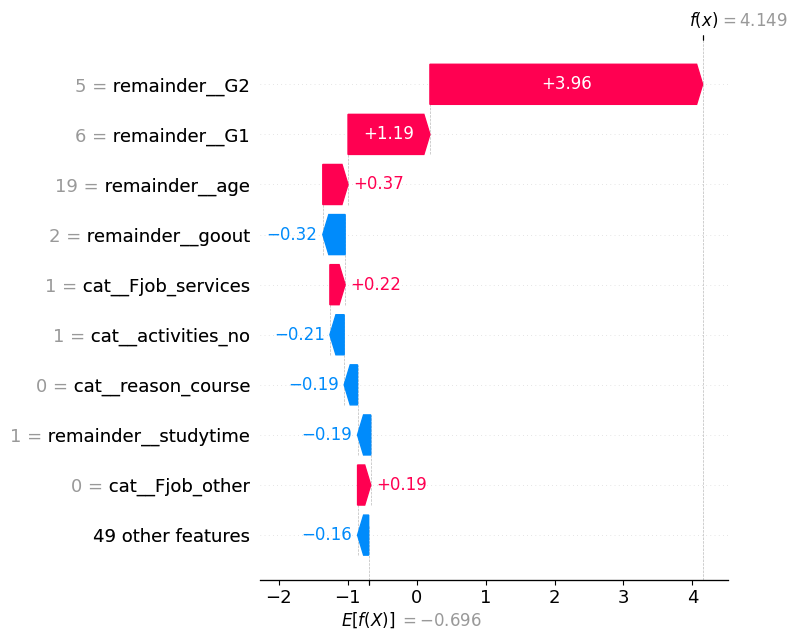

In [51]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=X_test_transformed[0],
        feature_names=feature_names
    ),
    show=False
)

plt.tight_layout()
plt.savefig(
    "shap_waterfall.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Intervention Recommendation

In [33]:
def generate_intervention(row):
    recommendations = []

    if row["absences"] > 10:
        recommendations.append("Attendance counselling")

    if row["failures"] >= 1:
        recommendations.append("Remedial classes")

    if row["studytime"] <= 1:
        recommendations.append("Study plan support")

    if row["goout"] >= 4:
        recommendations.append("Reduce distractions / mentoring")

    if row["famsup"] == "no":
        recommendations.append("Family support follow-up")

    if row["schoolsup"] == "no":
        recommendations.append("Offer school support")

    if len(recommendations) == 0:
        recommendations.append("Continue monitoring")

    return recommendations

In [34]:
# Dataframe containing predictions
results = X_test.copy()

results["Actual_Risk"] = y_test.values
results["Predicted_Risk"] = y_pred_B

results["Interventions"] = results.apply(
    generate_intervention,
    axis=1
)

In [35]:
results['Interventions'].head()

383    [Remedial classes, Study plan support, Family ...
19     [Study plan support, Family support follow-up,...
193           [Study plan support, Offer school support]
343             [Remedial classes, Offer school support]
92                                 [Continue monitoring]
Name: Interventions, dtype: object

In [36]:
results[
    results["Predicted_Risk"] == 1
][[
    "failures",
    "absences",
    "studytime",
    "goout",
    "Actual_Risk",
    "Predicted_Risk",
    "Interventions"
]].head(10)

,failures,absences,studytime,goout,Actual_Risk,Predicted_Risk,Interventions
383,1,0,1,2,1,1,"[Remedial classes, Study plan support, Family ..."
193,0,8,1,2,0,1,"[Study plan support, Offer school support]"
343,1,0,2,1,1,1,"[Remedial classes, Offer school support]"
92,0,4,2,3,1,1,[Continue monitoring]
297,0,10,2,5,1,1,"[Reduce distractions / mentoring, Offer school..."
135,0,0,3,3,1,1,[Offer school support]
75,0,6,2,3,0,1,[Offer school support]
242,0,0,1,5,1,1,"[Study plan support, Reduce distractions / men..."
197,0,8,1,4,0,1,"[Study plan support, Reduce distractions / men..."
334,0,0,4,4,1,1,"[Reduce distractions / mentoring, Family suppo..."


# Pickle

In [37]:
import joblib

joblib.dump(
    xgb_model_B,
    "student_risk_model.pkl"
)

['student_risk_model.pkl']

In [38]:
import os

os.listdir()

['.ipynb_checkpoints',
 'app.py',
 'EDA.ipynb',
 'Feature.ipynb',
 'student-mat.csv',
 'student_risk_model.pkl']

# Final Model

Model: XGBoost

Features:
- G1
- G2
- Attendance
- Behavioural Factors

Performance:
- Accuracy: 91.1%
- Recall (At-Risk): 85%
- F1 Score (At-Risk): 86%

# Requirements

In [47]:
from importlib.metadata import version, PackageNotFoundError

for p in ["pandas", "numpy", "scikit-learn", "xgboost", "streamlit", "shap", "matplotlib", "seaborn", "joblib"]:
    try:
        print(f"{p}=={version(p)}")
    except PackageNotFoundError:
        pass

pandas==3.0.1
numpy==2.4.2
scikit-learn==1.8.0
xgboost==3.2.0
shap==0.52.0
matplotlib==3.10.8
seaborn==0.13.2
joblib==1.5.3


# Conclusion

An XGBoost-based student risk prediction system was developed using academic, demographic, and behavioural features.

The final model achieved:

- Accuracy: 91.1%
- Recall (At-Risk Students): 85%
- F1 Score: 86%

SHAP was used to explain model predictions, and a Streamlit dashboard was created to allow faculty members to upload student data, identify high-risk students, and generate intervention recommendations.